In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q langchain
!pip install -q langchain-community
!pip install -q ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!curl https://ollama.ai/install.sh | sh

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13281    0 13281    0     0  37821      0 --:--:-- --:--:-- --:--:-- 37730
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
!ollama serve > rocama.log 2>&1 &
!ollama pull aya-expanse

# Open the book file

In [ ]:
from bs4 import BeautifulSoup
import re

with open('/content/drive/MyDrive/KETAB1.htm', 'r', encoding='utf-8') as file:
    html_content = file.read()


soup = BeautifulSoup(html_content, 'html.parser')
raw_text = soup.get_text(separator='\n')

# Split lines and strip whitespace
lines = [line.strip() for line in raw_text.split('\n')]

# Filter out lines that are completely empty or only whitespace
filtered_lines = [line for line in lines]

# Join with newlines
text_with_single_blank_lines = '\n'.join(filtered_lines)

# Use regex to replace multiple blank lines with just one blank line
clean_text = re.sub(r'\n\s*\n+', '\n\n', text_with_single_blank_lines).strip()

# print(clean_text)

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Start with a medium-sized chunk, but prioritize paragraph boundaries.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # Target size in characters/tokens
    chunk_overlap=100,  # CRITICAL: Overlap between chunks to avoid losing context
    separators=["\n\n", "\n", " ", ""]  # Splitting hierarchy
)

chunks = text_splitter.split_text(clean_text)

In [ ]:
chunks[1]

'ص: 3\n\nص: 4\n\nشناسنامه\n\nمتن پیش رو صد و بیست و ششمین مکتوب از نوع ششم محصولات مرتبط با نقشه الگوی پیشرفت اسلامی (پیاده (فوری) است. محتوای این محصول متن پیاده شده گفتگوی حجت الاسلام و المسلمین علی کشوری دبیر شورای راهبردی الگوی پیشرفت اسلامی در نشست تخصصی تبیین الگوی فقهی تحلیل و مهار تورم ایراد شده است. این نشست در تاریخ 20 اردیبهشت ماه 1402 در شهر مبارک قم برگزار شده است. شایان ذکر است که بحث از الگوی فقهی تحلیل و مهار تورم، زیر مجموعه مباحث "فقه المكاسب" است. ضمناً بحث حاضر حاوی جدول تصمیم مشتمل بر چهار تصمیم) میباشد. پیشنهاد می شود این جزوه در قطع رحلی به انتشار برسد.\n\nص: 5\n\nص: 6\n\nعکس\n\nص: 7\n\nص: 8\n\nفهرست مطالب:\n\nمقدمه: مروری اجمالی بر سرفصل ها و سوالات مطرح در جلسه 1\n\n1. سرفصل اول: روش تحقیق فقهی در حوزه مسائل اقتصادی و مسئله تورّم چگونه است؟ 7\n\n1/1. کارآمدی روش تحقیق فقهی در حوزه مسائل اقتصادی و مسئله تورّم (به دلیل وجود "اِشراف" و "جامعیت")، نسبت به گزاره های اقتصاد کلان؛ ویژگی مهم روش تحقیق فقهی. 7'

# Extract all leaf nodes form categories file

In [ ]:
import json
def extract_leaf_nodes(category_tree, current_path=None):
    """
    Recursively extract all leaf nodes from the category tree.
    Leaf nodes are categories that don't have any subcategories.
    """
    if current_path is None:
        current_path = []

    leaf_nodes = []

    for category_name, category_data in category_tree.items():
        # Skip the _url key as it's not a category
        if category_name == "_url":
            continue

        new_path = current_path + [category_name]

        # Check if this is a leaf node (no subcategories except possibly _url)
        is_leaf = True
        for key in category_data.keys():
            if key != "_url":
                is_leaf = False
                break

        if is_leaf:
            leaf_nodes.append(" > ".join(new_path))
        else:
            # Recursively process subcategories
            sub_leaf_nodes = extract_leaf_nodes(category_data, new_path)
            leaf_nodes.extend(sub_leaf_nodes)

    return leaf_nodes

# category tree data
with open("/content/drive/MyDrive/category_tree.json","r") as file:
    category_tree = json.load(file)

# Extract all leaf nodes
leaf_nodes = extract_leaf_nodes(category_tree)

# Display the results
# print(f"Total leaf nodes found: {len(leaf_nodes)}")
# print("\nFirst 20 leaf nodes:")
# for i, node in enumerate(leaf_nodes[:20]):
#     print(f"{i+1}. {node}")

# print(f"\nLast 10 leaf nodes:")
# for i, node in enumerate(leaf_nodes[-10:], len(leaf_nodes)-9):
#     print(f"{i}. {node}")

# The leaf_nodes list now contains all the leaf categories

In [ ]:
len(leaf_nodes)

852

In [ ]:
leaf_nodes[100]

'04- معصومین علیهم السلام > 1- چهارده معصوم علیهم السلام > 01- پیامبر اکرم، حضرت محمد (صلی الله علیه و آله) > 21- ازدواج پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)'

# Minimized category

In [ ]:
import json

path = '/content/drive/MyDrive/automated_tagging/quick_consolidation_results.json'
# Load the JSON data
with open(path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# Function to recursively extract leaf categories
def extract_leaf_categories(category_dict, leaf_list=None, current_path=""):
    if leaf_list is None:
        leaf_list = []

    for category_name, category_data in category_dict.items():
        full_path = f"{current_path} > {category_name}" if current_path else category_name

        # Check if this is a leaf category
        if category_data.get('is_leaf', False):
            leaf_list.append({
                'full_path': full_path,
                'book_count': category_data.get('book_count', 0),
                'url': category_data.get('url', '')
            })
        # If it has subcategories, recursively process them
        elif 'subcategories' in category_data:
            extract_leaf_categories(category_data['subcategories'], leaf_list, full_path)

    return leaf_list

# Extract all leaf categories from the consolidated tree
leaf_categories = extract_leaf_categories(data['consolidated_tree'])

# Print the results
print(f"Total leaf categories found: {len(leaf_categories)}")
print("\nFirst 10 leaf categories:")
for i, leaf in enumerate(leaf_categories[:10]):
    print(f"{i+1}. {leaf['full_path']} (Books: {leaf['book_count']})")

# The leaf_categories list now contains all leaf categories
print(f"\nAll leaf categories are stored in the 'leaf_categories' list")
print(f"Total count: {len(leaf_categories)}")

# If you just want the names/paths in a simple list:
leaf_names = [leaf['full_path'] for leaf in leaf_categories]
print(f"\nSimple list of leaf category paths (first 5):")
for name in leaf_names[:5]:
    print(f"- {name}")

Total leaf categories found: 335

First 10 leaf categories:
1. 00- نرم افزارهای کاربردی (Books: 54)
2. 000- کتاب های صوتی > 13- علوم حوزوی > 01- سخنرانی ها > 01- حجت الاسلام نبوی (Books: 24)
3. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 01- آیت الله سبحانی (Books: 18)
4. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 03- آیت الله مکارم شیرازی (Books: 18)
5. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 04- آیت الله جوادی آملی (Books: 18)
6. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 05- آیت الله نوری همدانی (Books: 10)
7. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 07- آیت الله مصطفوی نیا (Books: 18)
8. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 08- آیت الله هاشمی شاهرودی (Books: 14)
9. 000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 18- استاد حشمت پور (Books: 25)
10. 01- معارف قرآنی > 1- دانستنیها و کلیات و ... (Books: 386)

All leaf categories are stored in the 'leaf_categories' list
Total count: 335

Simple list of leaf category paths (first 5):
- 00- نر

In [ ]:
import json

path = '/content/drive/MyDrive/automated_tagging/quick_consolidation_results.json'
# Load the JSON data
with open(path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# Function to recursively extract leaf category names (last part only)
def extract_leaf_names(category_dict, leaf_list=None):
    if leaf_list is None:
        leaf_list = []

    for category_name, category_data in category_dict.items():
        # Check if this is a leaf category
        if category_data.get('is_leaf', False):
            leaf_list.append(category_name)
        # If it has subcategories, recursively process them
        elif 'subcategories' in category_data:
            extract_leaf_names(category_data['subcategories'], leaf_list)

    return leaf_list

# Extract all leaf category names (last part only)
leaf_names = extract_leaf_names(data['consolidated_tree'])

# Print the results
print(f"Total leaf categories found: {len(leaf_names)}")
print("\nFirst 20 leaf category names:")
for i, name in enumerate(leaf_names[:20]):
    print(f"{i+1}. {name}")

print(f"\nAll leaf category names are stored in the 'leaf_names' list")
print(f"Total count: {len(leaf_names)}")

# Display some statistics
print(f"\nSample of leaf names:")
print(f"- First: {leaf_names[0]}")
print(f"- Last: {leaf_names[-1]}")
print(f"- Random samples: {leaf_names[50]}, {leaf_names[100]}, {leaf_names[150]}")

Total leaf categories found: 335

First 20 leaf category names:
1. 00- نرم افزارهای کاربردی
2. 01- حجت الاسلام نبوی
3. 01- آیت الله سبحانی
4. 03- آیت الله مکارم شیرازی
5. 04- آیت الله جوادی آملی
6. 05- آیت الله نوری همدانی
7. 07- آیت الله مصطفوی نیا
8. 08- آیت الله هاشمی شاهرودی
9. 18- استاد حشمت پور
10. 1- دانستنیها و کلیات و ...
11. 2- قرآن (متن و ترجمه و آوانوشت)
12. 1- تفسیر اهل بیت علیهم السلام
13. 2- سایر کتب تفسیر
14. 3- تفسیر سور
15. 4- تفسیر و تاویل آیات خاص
16. 2- تفسیر پژوهی
17. 3- تفسیر موضوعی و تطبیقی
18. 1- اعجاز قرآن
19. 2- تحریف ناپذیری قرآن
20. 20- علم مفاهیم شناسی در قرآن

All leaf category names are stored in the 'leaf_names' list
Total count: 335

Sample of leaf names:
- First: 00- نرم افزارهای کاربردی
- Last: 2- نسخه خطی
- Random samples: 11- فدك حضرت فاطمه زهرا (سلام الله علیها), 08- سیره مهدویه امام زمان، حضرت مهدی (عجل الله تعالی فرجه), 1- دنیا و آخرت


In [ ]:
import json

# Load the JSON data
with open(path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# Function to extract just the last part of each leaf category
def extract_last_part_only(category_dict, leaf_list=None):
    if leaf_list is None:
        leaf_list = []

    for category_name, category_data in category_dict.items():
        # Check if this is a leaf category
        if category_data.get('is_leaf', False):
            # Extract just the last part (after the last '>')
            parts = category_name.split(' > ')
            last_part = parts[-1] if ' > ' in category_name else category_name
            leaf_list.append(last_part)
        # If it has subcategories, recursively process them
        elif 'subcategories' in category_data:
            extract_last_part_only(category_data['subcategories'], leaf_list)

    return leaf_list

# Extract just the last part of each leaf category
leaf_last_parts = extract_last_part_only(data['consolidated_tree'])

# Print the results
print(f"Total leaf categories found: {len(leaf_last_parts)}")
print("\nFirst 20 leaf category names (last part only):")
for i, name in enumerate(leaf_last_parts[:20]):
    print(f"{i+1}. {name}")

print(f"\nAll leaf category names (last parts) are stored in the 'leaf_last_parts' list")
print(f"Total count: {len(leaf_last_parts)}")

# Display some examples to verify the extraction
print(f"\nExamples of extracted last parts:")
print(f"- '000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 03- آیت الله مکارم شیرازی' → '{leaf_last_parts[2]}'")
print(f"- '01- معارف قرآنی > 1- دانستنیها و کلیات و ...' → '{leaf_last_parts[5]}'")

Total leaf categories found: 335

First 20 leaf category names (last part only):
1. 00- نرم افزارهای کاربردی
2. 01- حجت الاسلام نبوی
3. 01- آیت الله سبحانی
4. 03- آیت الله مکارم شیرازی
5. 04- آیت الله جوادی آملی
6. 05- آیت الله نوری همدانی
7. 07- آیت الله مصطفوی نیا
8. 08- آیت الله هاشمی شاهرودی
9. 18- استاد حشمت پور
10. 1- دانستنیها و کلیات و ...
11. 2- قرآن (متن و ترجمه و آوانوشت)
12. 1- تفسیر اهل بیت علیهم السلام
13. 2- سایر کتب تفسیر
14. 3- تفسیر سور
15. 4- تفسیر و تاویل آیات خاص
16. 2- تفسیر پژوهی
17. 3- تفسیر موضوعی و تطبیقی
18. 1- اعجاز قرآن
19. 2- تحریف ناپذیری قرآن
20. 20- علم مفاهیم شناسی در قرآن

All leaf category names (last parts) are stored in the 'leaf_last_parts' list
Total count: 335

Examples of extracted last parts:
- '000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 03- آیت الله مکارم شیرازی' → '01- آیت الله سبحانی'
- '01- معارف قرآنی > 1- دانستنیها و کلیات و ...' → '05- آیت الله نوری همدانی'


In [ ]:
import json
import re

path = '/content/drive/MyDrive/automated_tagging/quick_consolidation_results.json'

# Load the JSON data
with open(path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# Function to extract last part and remove numbers
def extract_clean_leaf_names(category_dict, leaf_list=None):
    if leaf_list is None:
        leaf_list = []

    for category_name, category_data in category_dict.items():
        # Check if this is a leaf category
        if category_data.get('is_leaf', False):
            # Extract just the last part (after the last '>')
            parts = category_name.split(' > ')
            last_part = parts[-1] if ' > ' in category_name else category_name

            # Remove numbers and hyphens at the beginning
            # This removes patterns like "01-", "1-", "03-" etc.
            clean_name = re.sub(r'^\d+\s*-\s*', '', last_part)

            leaf_list.append(clean_name)
        # If it has subcategories, recursively process them
        elif 'subcategories' in category_data:
            extract_clean_leaf_names(category_data['subcategories'], leaf_list)

    return leaf_list

# Extract clean leaf names (last part without numbers)
clean_leaf_names = extract_clean_leaf_names(data['consolidated_tree'])

# Print the results
print(f"Total leaf categories found: {len(clean_leaf_names)}")
print("\nFirst 30 clean leaf category names:")
for i, name in enumerate(clean_leaf_names[:30]):
    print(f"{i+1}. {name}")

print(f"\nAll clean leaf category names are stored in the 'clean_leaf_names' list")
print(f"Total count: {len(clean_leaf_names)}")

# Display some examples to show the transformation
print(f"\nExamples of transformation:")
sample_categories = [
    "000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 03- آیت الله مکارم شیرازی",
    "01- معارف قرآنی > 1- دانستنیها و کلیات و ...",
    "04- معصومین علیهم السلام > 1- چهارده معصوم علیهم السلام > 01- پیامبر اکرم، حضرت محمد (صلی الله علیه و آله) > 01- دانستنیها و کلیات پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)",
    "12- فقه و احكام > 01- رساله های احکام > 1- توضیح المسائل"
]

for i, category in enumerate(sample_categories):
    last_part = category.split(' > ')[-1]
    clean_name = re.sub(r'^\d+\s*-\s*', '', last_part)
    print(f"{i+1}. '{category}'")
    print(f"   → Last part: '{last_part}'")
    print(f"   → Clean: '{clean_name}'")
    print()

Total leaf categories found: 335

First 30 clean leaf category names:
1. نرم افزارهای کاربردی
2. حجت الاسلام نبوی
3. آیت الله سبحانی
4. آیت الله مکارم شیرازی
5. آیت الله جوادی آملی
6. آیت الله نوری همدانی
7. آیت الله مصطفوی نیا
8. آیت الله هاشمی شاهرودی
9. استاد حشمت پور
10. دانستنیها و کلیات و ...
11. قرآن (متن و ترجمه و آوانوشت)
12. تفسیر اهل بیت علیهم السلام
13. سایر کتب تفسیر
14. تفسیر سور
15. تفسیر و تاویل آیات خاص
16. تفسیر پژوهی
17. تفسیر موضوعی و تطبیقی
18. اعجاز قرآن
19. تحریف ناپذیری قرآن
20. علم مفاهیم شناسی در قرآن
21. تجوید و قرائت
22. نزول قرآن
23. مهدی عجل الله تعالی فرجه الشریف در قرآن
24. دانستنیها و کلیات
25. نهج البلاغه (متن و ترجمه و گزیده)
26. شرح
27. نهج البلاغه موضوعی
28. دانستنیها و کلیات
29. صحیفه سجادیه
30. ترجمه

All clean leaf category names are stored in the 'clean_leaf_names' list
Total count: 335

Examples of transformation:
1. '000- کتاب های صوتی > 13- علوم حوزوی > 02- دروس > 03- آیت الله مکارم شیرازی'
   → Last part: '03- آیت الله مکارم شیرازی'
   → Cle

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_models import ChatOllama

tagging_prompt = ChatPromptTemplate.from_template(
"""
شما یک متخصص کتابدار هستید که متون فارسی را بر اساس یک سیستم طبقه‌بندی دقیق برچسب‌گذاری می‌کنید.

**فهرست برچسب‌های موجود (فقط از این لیست انتخاب کنید):**
{tag_list}

**دستورالعمل‌ها:**
- فقط برچسب‌هایی را انتخاب کنید که مستقیماً و به طور معناداری در متن مورد بحث قرار گرفته‌اند.
- متن را به دقت تحلیل کنید و برچسب‌های مرتبط را انتخاب نمایید.
- اگر موضوعی به طور واضح در متن وجود دارد ولی عبارت دقیق آن در لیست نیست، نزدیک‌ترین برچسب را انتخاب کنید.
- پاسخ را فقط به صورت JSON معتبر برگردانید با کلید "tags" که شامل لیستی از برچسب‌های انتخاب شده است.
-برچسب‌ها تنها باید از فهرست برچسب‌های موجود انتخاب شوند.
- ترتیب برچسب‌هادر خروجی اهمیت دارد. برچسب‌های مرتبط‌تر ابتدای فهرست خروجی قرار بگیرند.

**متن برای تحلیل:**
{text_chunk}

**خروجی (فقط JSON):**
"""
)



local_model = 'aya-expanse'
llm = ChatOllama(model = local_model)


/tmp/ipython-input-451591488.py:29: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(model = local_model)


In [ ]:
test_chunk = """
    شعر حافظ از جمله برجسته‌ترین آثار ادبیات فارسی است که تأثیر عمیقی بر فرهنگ ایرانی گذاشته است.
    غزلیات او مملو از مفاهیم عرفانی و فلسفی است که با زیبایی هرچه تمام بیان شده‌اند.
"""

# Sample tag list (you'll replace with your full list)
tag_list = """
ادبیات: شعر فارسی, نثر کلاسیک, ادبیات معاصر, نقد ادبی
فلسفه: فلسفه اسلامی, عرفان, فلسفه غرب, اخلاق
تاریخ: تاریخ ایران, تاریخ اسلام, تاریخ جهان
"""

In [ ]:
inp = chunks[1]
prompt = tagging_prompt.invoke({"tag_list": tag_list, "text_chunk": test_chunk})
answer = llm.invoke(prompt)
tags = answer.content

In [ ]:
tags

'```json\n{\n  "tags": ["ادبیات", "شعر فارسی", "عرفان", "فلسفه"]\n}\n```'

In [ ]:

# prompt = tagging_prompt.invoke({"tag_list": tag_list, "text_chunk": test_chunk})
prompt = tagging_prompt.invoke({"tag_list": leaf_names, "text_chunk": chunks[1]})
answer = llm.invoke(prompt)
tags = answer.content

In [ ]:
answer

AIMessage(content='```json\n{\n  "tags": ["ادبیات", "شعر فارسی", "عرفان", "فلسفه"]\n}\n```', additional_kwargs={}, response_metadata={'model': 'aya-expanse', 'created_at': '2025-09-25T12:40:54.242753389Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 226027430693, 'load_duration': 32688147060, 'prompt_eval_count': 364, 'prompt_eval_duration': 168747247156, 'eval_count': 31, 'eval_duration': 24586247168}, id='run--da78deb8-1d4b-436e-b395-101e71296a5c-0')

In [ ]:
prompt = tagging_prompt.invoke({"tag_list": leaf_names, "text_chunk": chunks[1]})
answer = llm.invoke(prompt)
tags = answer.content

In [ ]:
tags

'```json\n{\n  "tags": [\n    "فقه المكاسب",\n    "تحلیل تورم",\n    "روش تحقیق فقهی",\n    "مسائل اقتصادی",\n    "شورای راهبردی الگوی پیشرفت اسلامی",\n    "قم",\n    "20 اردیبهشت 1402"\n  ]\n}\n```'

In [ ]:
answer

AIMessage(content='```json\n{\n  "tags": [\n    "فقه المكاسب",\n    "تحلیل تورم",\n    "روش تحقیق فقهی",\n    "مسائل اقتصادی",\n    "شورای راهبردی الگوی پیشرفت اسلامی",\n    "قم",\n    "20 اردیبهشت 1402"\n  ]\n}\n```', additional_kwargs={}, response_metadata={'model': 'aya-expanse', 'created_at': '2025-09-25T14:06:04.362785627Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 2260698109309, 'load_duration': 41872082221, 'prompt_eval_count': 4096, 'prompt_eval_duration': 2140802413655, 'eval_count': 75, 'eval_duration': 77939784223}, id='run--a6e9e520-12ad-4fb5-9704-4a106bf042ef-0')

In [ ]:
tags1='json\n{\n  "tags": [\n    "فقه المكاسب",\n    "تحلیل تورم",\n    "روش تحقیق فقهی",\n    "مسائل اقتصادی",\n    "شورای راهبردی الگوی پیشرفت اسلامی",\n    "قم",\n    "20 اردیبهشت 1402"\n  ]\n}\n'

In [ ]:
# Remove the 'json\n' prefix
cleaned_tags = tags1.lstrip('json\n')

# Now parse the cleaned string
data = json.loads(cleaned_tags)

# Pretty-print
pretty_json = json.dumps(data, ensure_ascii=False, indent=4)
print(pretty_json)

{
    "tags": [
        "فقه المكاسب",
        "تحلیل تورم",
        "روش تحقیق فقهی",
        "مسائل اقتصادی",
        "شورای راهبردی الگوی پیشرفت اسلامی",
        "قم",
        "20 اردیبهشت 1402"
    ]
}


In [ ]:
for each in data['tags']:
  print(each)

فقه المكاسب
تحلیل تورم
روش تحقیق فقهی
مسائل اقتصادی
شورای راهبردی الگوی پیشرفت اسلامی
قم
20 اردیبهشت 1402


In [ ]:
prompt = tagging_prompt.invoke({"tag_list": clean_leaf_names, "text_chunk": chunks[1]})
answer = llm.invoke(prompt)
tags = answer.content

In [ ]:
tags1 = 'json\n{\n  "tags": [\n    "آیت الله سبحانی",\n    "تفسیر اهل بیت علیهم السلام",\n    "تفسیر سور",\n    "دانستنیها و کلیات پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)",\n    "فقه المكاسب",\n    "تحلیل و مهار تورم",\n    "شورای راهبردی الگوی پیشرفت اسلامی",\n    "مطالعات اقتصادی اسلامی"\n  ]\n}\n'
cleaned_tags = tags1.lstrip('json\n')

# Now parse the cleaned string
data = json.loads(cleaned_tags)

# Pretty-print
pretty_json = json.dumps(data, ensure_ascii=False, indent=4)
print(pretty_json)

{
    "tags": [
        "آیت الله سبحانی",
        "تفسیر اهل بیت علیهم السلام",
        "تفسیر سور",
        "دانستنیها و کلیات پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)",
        "فقه المكاسب",
        "تحلیل و مهار تورم",
        "شورای راهبردی الگوی پیشرفت اسلامی",
        "مطالعات اقتصادی اسلامی"
    ]
}


In [ ]:
len(chunks)

1109

In [ ]:
tags

'```json\n{\n  "tags": [\n    "آیت الله سبحانی",\n    "تفسیر اهل بیت علیهم السلام",\n    "تفسیر سور",\n    "دانستنیها و کلیات پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)",\n    "فقه المكاسب",\n    "تحلیل و مهار تورم",\n    "شورای راهبردی الگوی پیشرفت اسلامی",\n    "مطالعات اقتصادی اسلامی"\n  ]\n}\n```'

In [ ]:
import re
clean_tags = re.sub('```', '', tags)

clean_tags = clean_tags.lstrip('json\n')

# Parse the JSON string
data = json.loads(clean_tags)

# Extract the list
tags_list = data["tags"]

print(tags_list)

['آیت الله سبحانی', 'تفسیر اهل بیت علیهم السلام', 'تفسیر سور', 'دانستنیها و کلیات پیامبر اکرم، حضرت محمد (صلی الله علیه و آله)', 'فقه المكاسب', 'تحلیل و مهار تورم', 'شورای راهبردی الگوی پیشرفت اسلامی', 'مطالعات اقتصادی اسلامی']


# Labeling chunks

In [ ]:
from tqdm import tqdm
import json
import re

result_list = []

for chunk in tqdm(chunks, desc="Tagging chunks"):
  result = {}
  result['text_chunk'] = chunk
  prompt = tagging_prompt.invoke({"tag_list": clean_leaf_names, "text_chunk": chunk})
  answer = llm.invoke(prompt)
  tags = answer.content
  clean_tags = re.sub('```', '', tags)
  try:
    clean_tags = clean_tags.lstrip('json\n')

    # Parse the JSON string
    data = json.loads(clean_tags)

    # Extract the list
    tags_list = data["tags"]

    result['tags'] = tags_list
  except:
    result['tags'] = False

  result_list.append(result)


output_path = '/content/drive/MyDrive/automated_tagging/doc1_tags.json'
with open(output_path, 'w', encoding='utf-8-sig') as f:
    json.dump(result_list, f, ensure_ascii=False, indent=2)

print(f"Saved {len(result_list)} tagged chunks to {output_path}")

Tagging chunks:   6%|▌         | 69/1109 [05:53<1:28:41,  5.12s/it]


KeyboardInterrupt: 

In [ ]:
clean_tags

'{\n  "tags": [\n    "اقتصاد", \n    "جهانی شدن (العولمة)", \n    "پرسشهای فقهی (استفتاءات، اجوبه المسائل و ...)",\n    "حکومت اسلامی" \n  ]\n}\n \n\n**توضیح:**\n\n* **"اقتصاد"**: متن به تأثیر دلار بر کسب و کار مردم می\u200cپردازد که موضوعی اقتصادی است.\n* **"جهانی شدن (العولمة)"**:  مفهوم سلطه دلار می\u200cتواند در چارچوب جهانی شدن و تسلط نهادهای مالی بین\u200cالمللی بررسی شود.\n* **"پرسشهای فقهی (استفتاءات، اجوبه المسائل و ...)"**:  اگرچه متن به طور مستقیم فقهی نیست، اما به عنوان یک وبسایت اسلامی، ممکن است مخاطبان آن به دنبال پاسخ به پرسش\u200cهای شرعی در زمینه معاملات اقتصادی باشند.\n* **"حکومت اسلامی"**: با توجه به اشاره به "قم" به عنوان منبع و  تمرکز بر مسائل اجتماعی-اقتصادی، احتمال ارتباط با مباحث مربوط به حکومت اسلامی وجود دارد.'

In [ ]:
output_path = '/content/drive/MyDrive/automated_tagging/doc1_tags.json'
with open(output_path, 'w', encoding='utf-8-sig') as f:
    json.dump(result_list, f, ensure_ascii=False, indent=2)

print(f"Saved {len(result_list)} tagged chunks to {output_path}")

Saved 69 tagged chunks to /content/drive/MyDrive/automated_tagging/doc1_tags.json


# voting

In [ ]:
import json

file_path = '/content/drive/MyDrive/automated_tagging/doc1_tags.json'
with open(file_path, 'r', encoding = 'utf-8-sig') as f:
  tagged_chunks = json.load(f)

In [ ]:
tagged_chunks

[{'text_chunk': '\ufeff\n\nالگوی فقهی تحلیل و مهار تورم\n\nمشخصات کتاب\n\n126/6/1\n\nالگوی فقهی تحلیل و مهار تورم\n\nمحورهای جلسه\n\n1. روش تحقیق فقهی در حوزه مسائل اقتصادی و مسئله تورم چگونه است؟\n\n2. تحلیلهای ناقص مشهور درباره توزم کدام است؟ و چه اشکالاتی بر آنها وارد است؟\n\n3. نظریه فقه المکاسب برای تحلیل و مهار تورم چیست؟\n\n4 تصمیمات زیر ساختی فقه المکاسب برای مهار تورم کدام است؟\n\nشورای راهبردی\n\nالگوی پیشرفت اسلامی\n\n20 اردیبهشت ماه 1402\n\nص: 1\n\nاشاره\n\nص: 2\n\nبسم الله الرحمن الرحیم\n\nYour browser does not support the audio tag.\n\nوَكَأَيِّنْ مِنْ نَبِيَّ قَاتَلَ مَعَهُ رِيتُونَ كَثيرٌ فَما وَهَنُوا لِما أَصَابَهُمْ فِي سَبِيلِ اللَّهِ وَمَا ضَعُفُوا وَمَا اسْتَكَانُوا وَاللَّهُ يُحِبُّ الصَّابِرِينَ\n\nسوره مبارکه آل عمران، آیه 146\n\nو چه بسیار از پیامبرانی که مردان الهی فراوانی به همراه آنان ،جنگیدند، پس در مقابل آنچه در راه خدا به آنان رسید سستی نکردند و ناتوان نشدند و سر تسلیم و ذلت ف--رود نیاوردند؛ و خدا شکیبایان را دوست دارد\n\nص: 3\n\nص: 4\n\nشناسنامه',
  'ta

/tmp/ipython-input-3655726023.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(tags, fontproperties=farsi_font)
/tmp/ipython-input-3655726023.py:24: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
/tmp/ipython-input-3655726023.py:24: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


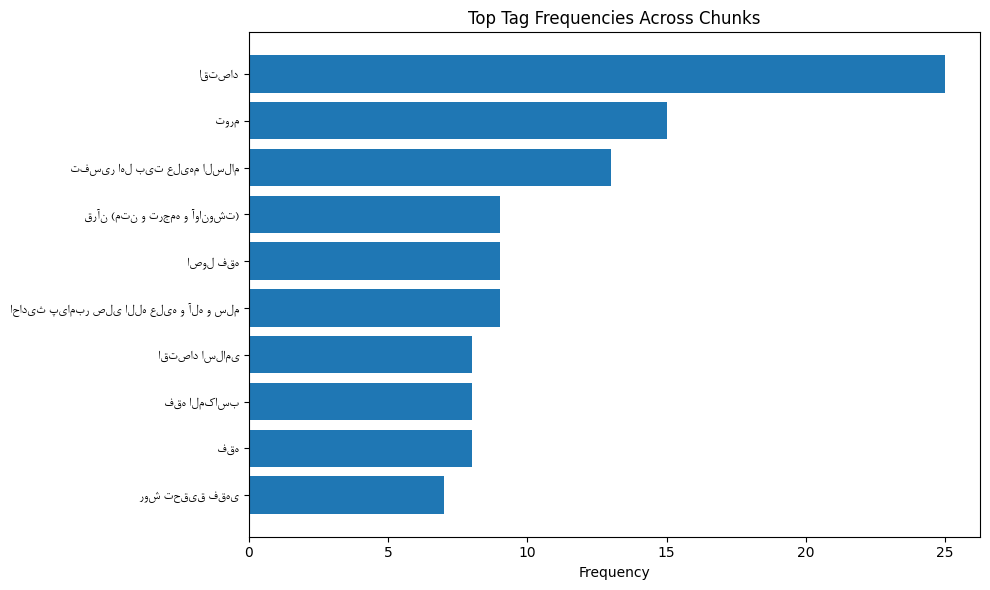

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Path to a font that supports Farsi/Arabic characters
# You need to download and specify the path to a .ttf font file
farsi_font_path = '/content/drive/MyDrive/B_NAZANIN/B-NAZANIN.TTF'
farsi_font = font_manager.FontProperties(fname=farsi_font_path)

def plot_tag_frequencies(tag_frequencies, top_n=10):
    sorted_tags = sorted(tag_frequencies.items(), key=lambda x: x[1], reverse=True)[:top_n]

    tags = [tag for tag, freq in sorted_tags]
    frequencies = [freq for tag, freq in sorted_tags]

    plt.figure(figsize=(10, 6))
    plt.barh(tags, frequencies)
    plt.xlabel('Frequency')
    plt.title('Top Tag Frequencies Across Chunks')
    plt.gca().invert_yaxis()  # Highest frequency at top

    # Apply the Farsi font to y-axis tick labels
    plt.gca().set_yticklabels(tags, fontproperties=farsi_font)

    plt.tight_layout()
    plt.show()

plot_tag_frequencies(tag_frequencies)

In [ ]:
!pip install arabic_reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 17.8 MB/s eta 0:00:00


/tmp/ipython-input-2875892166.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(tags, fontproperties=farsi_font)
/tmp/ipython-input-2875892166.py:32: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
/tmp/ipython-input-2875892166.py:32: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


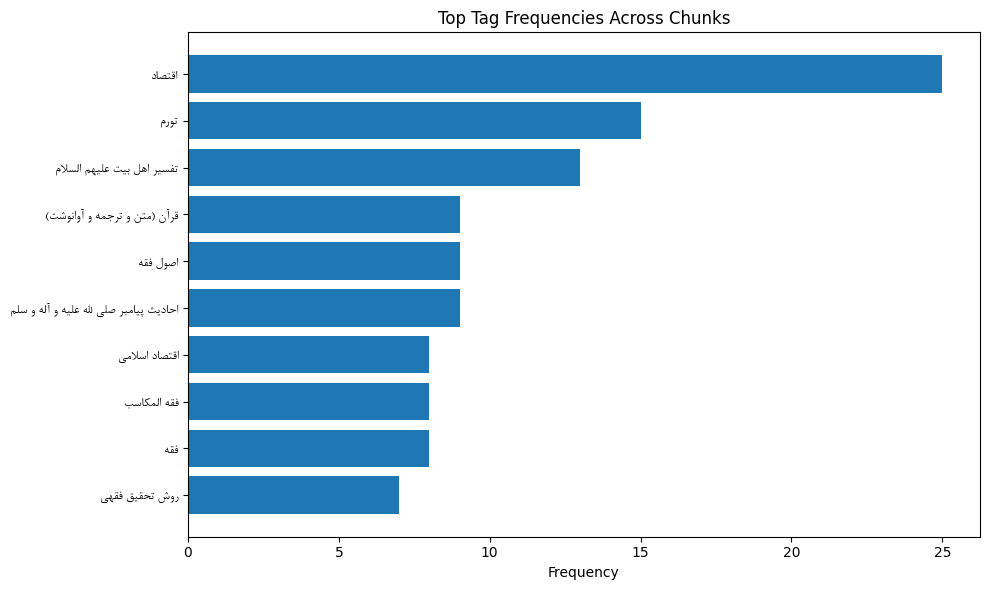

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Your Farsi-supporting font path (adjust this to your font file)
farsi_font_path = '/content/drive/MyDrive/B_NAZANIN/B-NAZANIN.TTF'
farsi_font = font_manager.FontProperties(fname=farsi_font_path)

def reshape_rtl_text(text):
    # Reshape Arabic characters and reorder for RTL display
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

def plot_tag_frequencies(tag_frequencies, top_n=10):
    sorted_tags = sorted(tag_frequencies.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Reshape and reorder Farsi tags for proper display
    tags = [reshape_rtl_text(tag) for tag, freq in sorted_tags]
    frequencies = [freq for tag, freq in sorted_tags]

    plt.figure(figsize=(10, 6))
    plt.barh(tags, frequencies)
    plt.xlabel('Frequency')
    plt.title('Top Tag Frequencies Across Chunks')
    plt.gca().invert_yaxis()

    # Use the Farsi font for the y-axis labels
    plt.gca().set_yticklabels(tags, fontproperties=farsi_font)

    plt.tight_layout()
    plt.show()

plot_tag_frequencies(tag_frequencies)

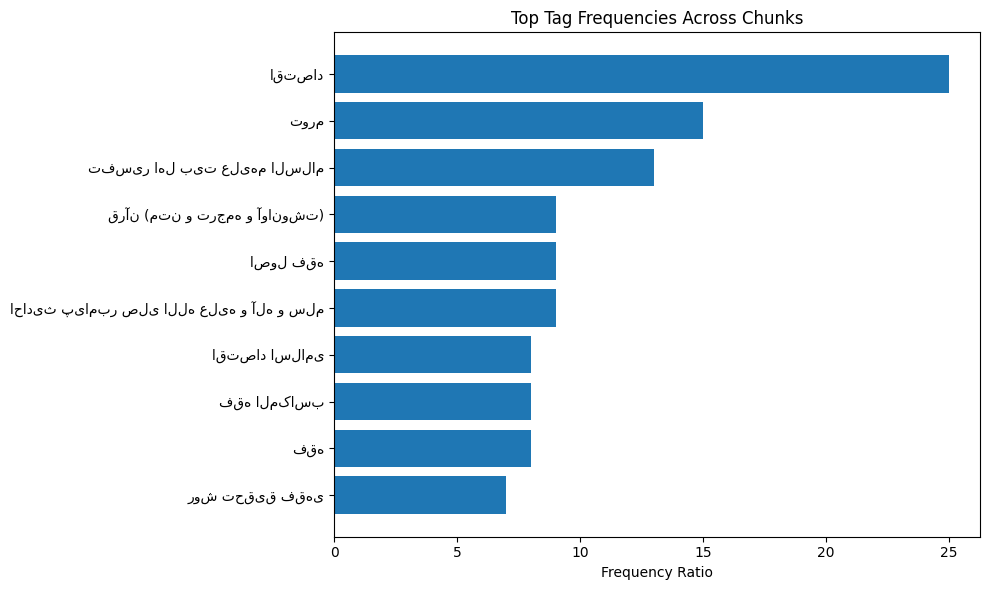

In [ ]:
import matplotlib.pyplot as plt

def plot_tag_frequencies(tag_frequencies, top_n=10):
    """Plot the most frequent tags"""
    sorted_tags = sorted(tag_frequencies.items(), key=lambda x: x[1], reverse=True)[:top_n]

    tags = [tag for tag, freq in sorted_tags]
    frequencies = [freq for tag, freq in sorted_tags]

    plt.figure(figsize=(10, 6))
    plt.barh(tags, frequencies)
    plt.xlabel('Frequency Ratio')
    plt.title('Top Tag Frequencies Across Chunks')
    plt.gca().invert_yaxis()  # Highest frequency at top
    plt.tight_layout()
    plt.show()

# Plot the results
# plot_tag_frequencies(tag_frequencies)

from collections import Counter

# Example structure of your data
data = [
    {"text_chunk": "Some text", "tags": ["python", "ai"]},
    {"text_chunk": "More content", "tags": ["python", "nlp"]},
    {"text_chunk": "Another bit", "tags": ["ai", "machine-learning"]},
    # ... more dictionaries
]

# Count tag frequencies
tag_frequencies = Counter()

for item in tagged_chunks:
  try:
    tags = item.get("tags", [])
    tag_frequencies.update(tags)
  except:
    pass

# Now call your plotting function
plot_tag_frequencies(tag_frequencies)


In [ ]:
len(clean_leaf_names)

335